<a href="https://colab.research.google.com/github/Tugume/AL-ML/blob/main/DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Check the GPU

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


Import all required libraries

In [2]:
import os
import zipfile
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision import models

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully.")

All libraries imported successfully.


Set random seeds

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


Connect Google Drive

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Locate the dataset

In [12]:
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.lower().endswith('.zip'):
            print(os.path.join(root, file))

/content/drive/MyDrive/Birds dataset.zip


Extract the dataset

In [13]:
zip_path = "/content/drive/MyDrive/Birds dataset.zip"
extract_path = "/content/birds_dataset"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("Dataset location:", extract_path)
print("Dataset extracted/available successfully.")

Dataset location: /content/birds_dataset
Dataset extracted/available successfully.


Define the bird dataset paths

In [14]:
train_path = "/content/birds_dataset/Birds dataset/train"
test_path = "/content/birds_dataset/Birds dataset/test"

print("Training path:", train_path)
print("Testing path:", test_path)

Training path: /content/birds_dataset/Birds dataset/train
Testing path: /content/birds_dataset/Birds dataset/test


Inspect the dataset structure

In [15]:
for root, dirs, files in os.walk(extract_path):

    level = root.replace(extract_path, '').count(os.sep)

    indent = ' ' * 4 * level

    print(f"{indent}{os.path.basename(root)}/")

    subindent = ' ' * 4 * (level + 1)

    for file in files[:5]:
        print(f"{subindent}{file}")

    if level >= 2:
        dirs[:] = []

birds_dataset/
    Birds dataset/
        train/
        test/
    cifar10-128/
        train/
        test/


Load the original dataset

In [16]:
original_train_dataset = ImageFolder(train_path)
original_test_dataset = ImageFolder(test_path)

print("Training images:", len(original_train_dataset))
print("Test images:", len(original_test_dataset))

print("Classes:", original_train_dataset.classes)
print("Number of classes:", len(original_train_dataset.classes))

Training images: 3000
Test images: 900
Classes: ['bird1', 'bird2', 'bird3']
Number of classes: 3


Define class names

In [17]:
class_names = original_train_dataset.classes
NUM_CLASSES = len(class_names)

print("Class names:", class_names)
print("Number of classes:", NUM_CLASSES)

Class names: ['bird1', 'bird2', 'bird3']
Number of classes: 3


Check class distribution

In [18]:
from collections import Counter

train_counts = Counter(
    label for _, label in original_train_dataset.samples
)

test_counts = Counter(
    label for _, label in original_test_dataset.samples
)

print("TRAINING DATA")

for class_index, count in sorted(train_counts.items()):
    print(f"{class_names[class_index]}: {count}")

print("\nTEST DATA")

for class_index, count in sorted(test_counts.items()):
    print(f"{class_names[class_index]}: {count}")

TRAINING DATA
bird1: 1000
bird2: 1000
bird3: 1000

TEST DATA
bird1: 300
bird2: 300
bird3: 300


Display sample birds

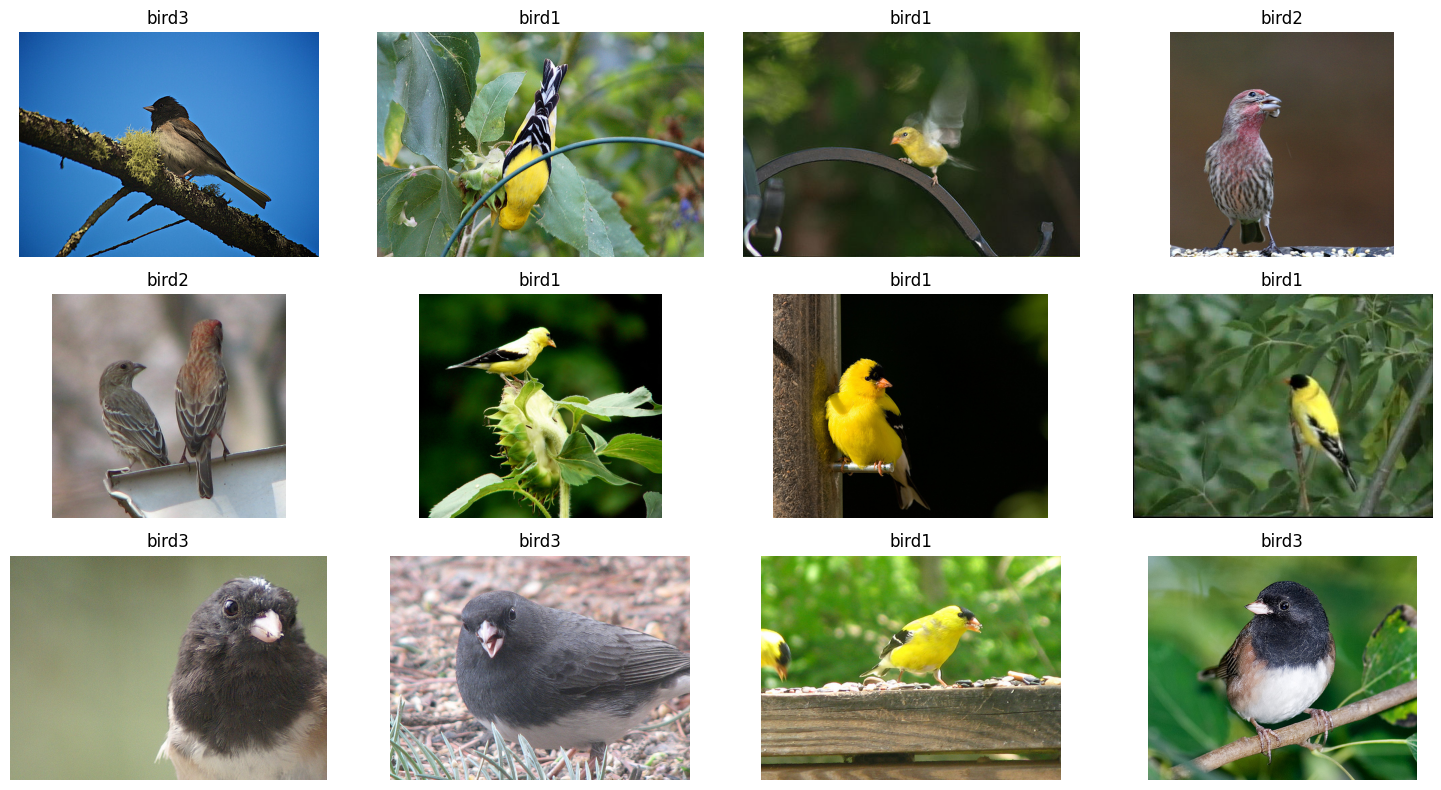

In [19]:
plt.figure(figsize=(15, 8))

for i in range(12):

    index = random.randint(
        0,
        len(original_train_dataset) - 1
    )

    image, label = original_train_dataset[index]

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

Check image dimensions

In [20]:
sizes = []

for path, label in original_train_dataset.samples[:100]:

    with Image.open(path) as img:
        sizes.append(img.size)

print("First 20 image sizes:")
print(sizes[:20])

print(
    "\nDifferent image sizes among first 100:",
    len(set(sizes))
)

First 20 image sizes:
[(500, 375), (500, 375), (500, 407), (581, 570), (500, 332), (333, 500), (500, 452), (469, 500), (405, 500), (500, 333), (500, 436), (500, 375), (500, 473), (500, 375), (500, 333), (500, 487), (500, 404), (399, 500), (333, 500), (500, 413)]

Different image sizes among first 100: 58


Define image size

In [21]:
IMAGE_SIZE = 224

print(
    f"Images will be processed at "
    f"{IMAGE_SIZE} × {IMAGE_SIZE}"
)

Images will be processed at 224 × 224


Create the training transformation

In [22]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.8, 1.0)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training transformation created.")

Training transformation created.


Create validation/test transformation

In [23]:
val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Validation/test transformation created.")

Validation/test transformation created.


Create the train/validation split

In [24]:
image_paths = [
    item[0]
    for item in original_train_dataset.samples
]

labels = [
    item[1]
    for item in original_train_dataset.samples
]

train_indices, val_indices = train_test_split(
    np.arange(len(labels)),
    test_size=0.20,
    random_state=SEED,
    stratify=labels
)

print("Training samples:", len(train_indices))
print("Validation samples:", len(val_indices))

Training samples: 2400
Validation samples: 600


Verify the split

In [25]:
train_labels = [
    labels[i]
    for i in train_indices
]

val_labels = [
    labels[i]
    for i in val_indices
]

print(
    "Training distribution:",
    Counter(train_labels)
)

print(
    "Validation distribution:",
    Counter(val_labels)
)

Training distribution: Counter({2: 800, 0: 800, 1: 800})
Validation distribution: Counter({2: 200, 1: 200, 0: 200})


Create the custom Dataset class

In [26]:
class BirdDataset(Dataset):

    def __init__(
        self,
        image_paths,
        labels,
        transform=None
    ):

        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        image = Image.open(
            self.image_paths[index]
        ).convert("RGB")

        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image, label

print("BirdDataset class created.")

BirdDataset class created.


Create the training dataset

In [27]:
train_images = [
    image_paths[i]
    for i in train_indices
]

train_labels = [
    labels[i]
    for i in train_indices
]

train_dataset = BirdDataset(
    train_images,
    train_labels,
    transform=train_transform
)

print("Training dataset size:", len(train_dataset))

Training dataset size: 2400


Create the validation dataset

In [28]:
val_images = [
    image_paths[i]
    for i in val_indices
]

val_labels = [
    labels[i]
    for i in val_indices
]

val_dataset = BirdDataset(
    val_images,
    val_labels,
    transform=val_test_transform
)

print("Validation dataset size:", len(val_dataset))

Validation dataset size: 600


Create the test dataset

In [29]:
test_dataset = ImageFolder(
    test_path,
    transform=val_test_transform
)

print("Test dataset size:", len(test_dataset))
print("Test classes:", test_dataset.classes)

Test dataset size: 900
Test classes: ['bird1', 'bird2', 'bird3']


Check one transformed image

In [30]:
image, label = train_dataset[0]

print("Image tensor shape:", image.shape)
print("Label:", label)
print("Class:", class_names[label])

Image tensor shape: torch.Size([3, 224, 224])
Label: 2
Class: bird3


Create DataLoaders

In [31]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


Check a complete batch

In [24]:
images, labels_batch = next(
    iter(train_loader)
)

print("Batch image shape:", images.shape)
print("Batch label shape:", labels_batch.shape)
print("Batch labels:", labels_batch)

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Batch labels: tensor([0, 2, 0, 1, 1, 0, 2, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2, 1, 0, 0, 1, 1, 0, 1,
        0, 0, 1, 1, 0, 1, 2, 2])


CUSTOM CNN

Define the custom CNN

In [32]:
class BirdCNN(nn.Module):

    def __init__(self, num_classes=3):

        super(BirdCNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                3, 32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(
                128, 256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # Global Average Pooling
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Dropout(0.5),

            nn.Linear(
                256,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

Instantiate the model

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BirdCNN(
    num_classes=NUM_CLASSES
).to(device)

print(model)

BirdCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

Check the model output

In [34]:
sample_images, sample_labels = next(
    iter(train_loader)
)

sample_images = sample_images.to(device)

output = model(sample_images)

print("Input shape:", sample_images.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 3])


Define the loss function

In [35]:
criterion = nn.CrossEntropyLoss()

print(criterion)

CrossEntropyLoss()


Define the optimizer

In [36]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


Define the learning-rate scheduler

In [37]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Learning-rate scheduler created.")

Learning-rate scheduler created.


Set training parameters

In [38]:
NUM_EPOCHS = 30

print("Number of epochs:", NUM_EPOCHS)

Number of epochs: 30


Train with validation monitoring

In [39]:
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(NUM_EPOCHS):

    # ==========================
    # TRAINING
    # ==========================

    model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    train_loss = (
        running_train_loss /
        len(train_loader)
    )

    train_accuracy = (
        100 * train_correct /
        train_total
    )


    # ==========================
    # VALIDATION
    # ==========================

    model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_loss = (
        running_val_loss /
        len(val_loader)
    )

    val_accuracy = (
        100 * val_correct /
        val_total
    )


    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)


    # Adjust learning rate
    scheduler.step(val_loss)


    # Save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            best_model_state,
            "best_bird_cnn.pth"
        )


    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/30] Train Loss: 0.9686 Train Acc: 54.79% Val Loss: 0.8958 Val Acc: 61.33%
Epoch [2/30] Train Loss: 0.8963 Train Acc: 61.75% Val Loss: 0.8685 Val Acc: 63.33%
Epoch [3/30] Train Loss: 0.8611 Train Acc: 63.50% Val Loss: 0.8579 Val Acc: 62.17%
Epoch [4/30] Train Loss: 0.8366 Train Acc: 65.25% Val Loss: 0.8274 Val Acc: 66.67%
Epoch [5/30] Train Loss: 0.8091 Train Acc: 68.38% Val Loss: 0.8077 Val Acc: 67.83%
Epoch [6/30] Train Loss: 0.8117 Train Acc: 67.04% Val Loss: 0.8551 Val Acc: 62.33%
Epoch [7/30] Train Loss: 0.7979 Train Acc: 68.12% Val Loss: 0.8885 Val Acc: 60.33%
Epoch [8/30] Train Loss: 0.7739 Train Acc: 68.92% Val Loss: 0.7933 Val Acc: 69.67%
Epoch [9/30] Train Loss: 0.7686 Train Acc: 70.38% Val Loss: 0.8237 Val Acc: 66.83%
Epoch [10/30] Train Loss: 0.7522 Train Acc: 71.00% Val Loss: 0.7647 Val Acc: 69.50%
Epoch [11/30] Train Loss: 0.7388 Train Acc: 72.17% Val Loss: 0.7887 Val Acc: 66.83%
Epoch [12/30] Train Loss: 0.7338 Train Acc: 71.00% Val Loss: 0.7698 Val Acc: 69.50%
E

Load the best validation model

In [40]:
model.load_state_dict(
    torch.load(
        "best_bird_cnn.pth",
        map_location=device
    )
)

model.eval()

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.2f}%"
)

Best validation accuracy: 74.33%


Plot training and validation loss

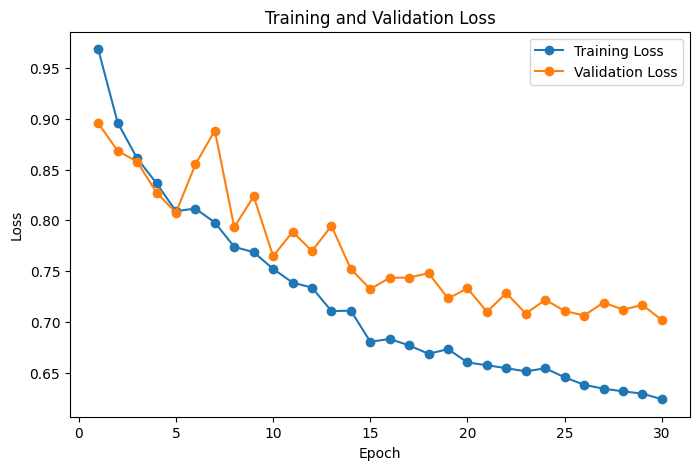

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

Plot training and validation accuracy

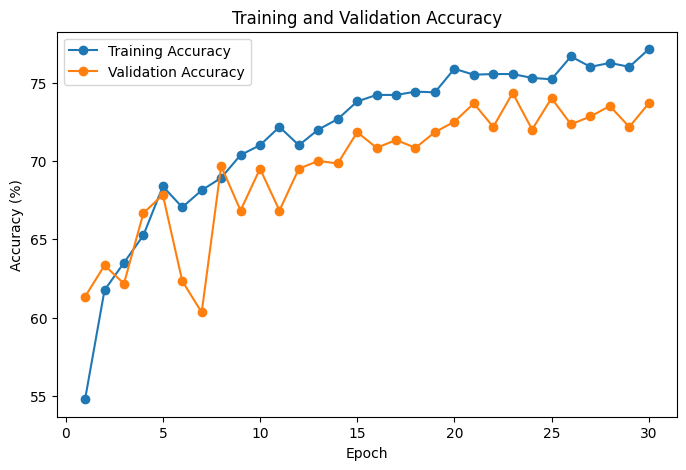

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

Evaluate the final custom CNN on the test set

Only now do we touch the 900-image test set for final evaluation.

In [43]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(
            outputs,
            1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

print(
    "Number of predictions:",
    len(all_predictions)
)

print(
    "Number of labels:",
    len(all_labels)
)

Number of predictions: 900
Number of labels: 900


Calculate test accuracy

In [44]:
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(
    f"Custom CNN Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Custom CNN Test Accuracy: 68.56%


Calculate precision, recall and F1

In [46]:
precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Precision: 0.6913
Recall:    0.6856
F1-score:  0.6868


Classification report

In [47]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       bird1       0.85      0.80      0.83       300
       bird2       0.63      0.57      0.60       300
       bird3       0.60      0.68      0.64       300

    accuracy                           0.69       900
   macro avg       0.69      0.69      0.69       900
weighted avg       0.69      0.69      0.69       900



Confusion matrix

[[241  26  33]
 [ 23 171 106]
 [ 19  76 205]]


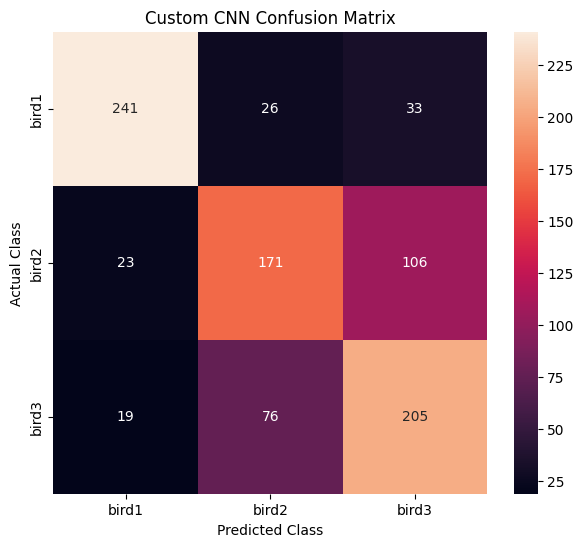

In [48]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

plt.figure(figsize=(7, 6))

import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Custom CNN Confusion Matrix")

plt.show()

Display sample predictions

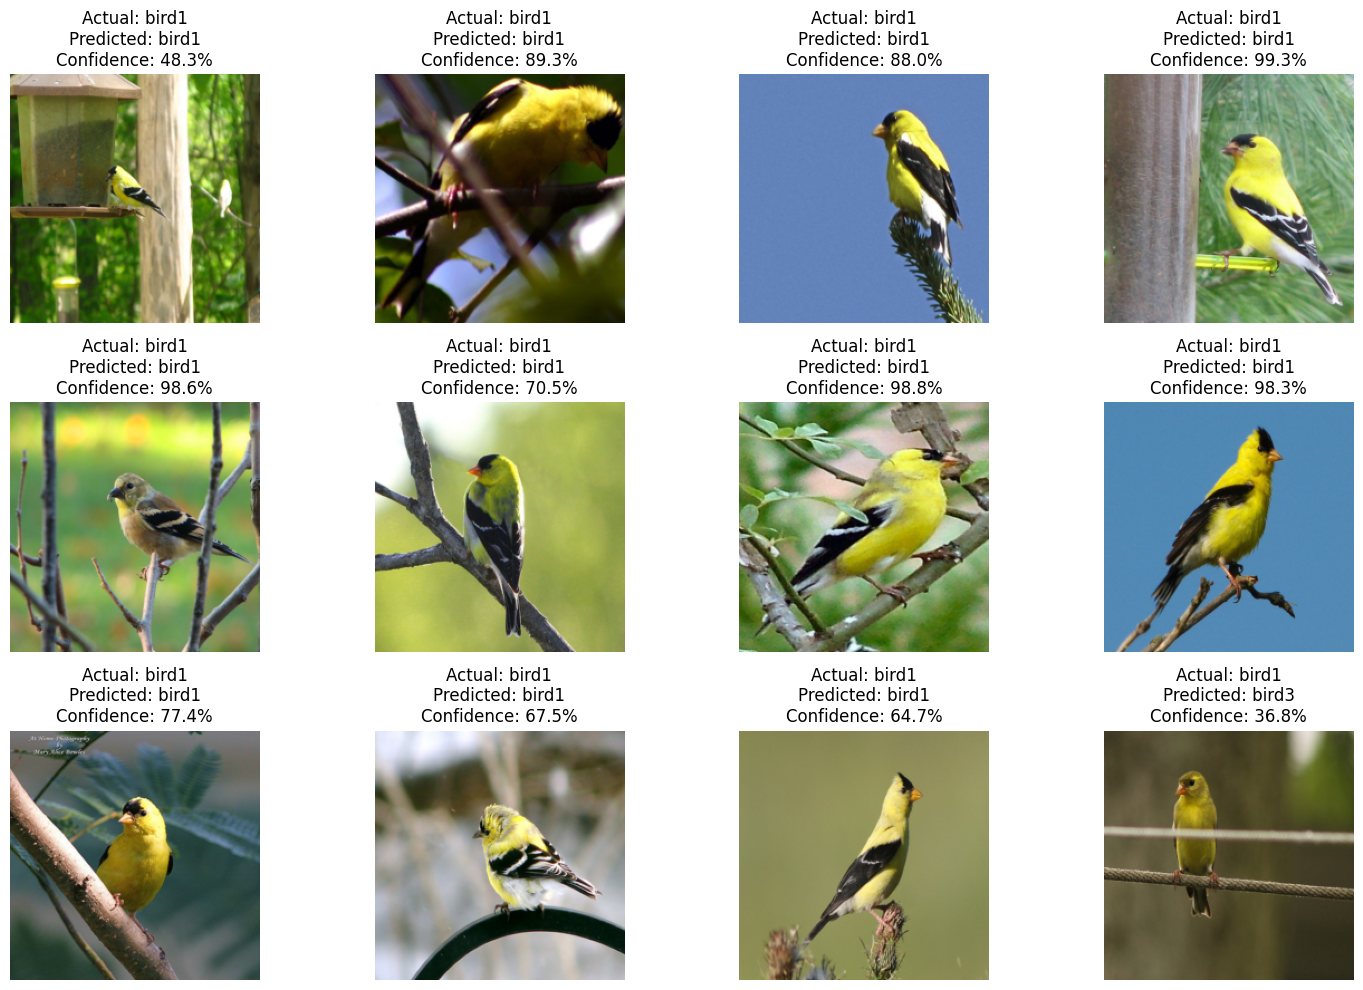

In [49]:
model.eval()

images, labels = next(
    iter(test_loader)
)

images_device = images.to(device)

with torch.no_grad():

    outputs = model(images_device)

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    confidences, predictions = torch.max(
        probabilities,
        1
    )

plt.figure(figsize=(15, 10))

mean = torch.tensor(
    [0.485, 0.456, 0.406]
)

std = torch.tensor(
    [0.229, 0.224, 0.225]
)

for i in range(min(12, len(images))):

    image = images[i].permute(1, 2, 0)

    image = image * std + mean

    image = torch.clamp(
        image,
        0,
        1
    )

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    actual = class_names[
        labels[i].item()
    ]

    predicted = class_names[
        predictions[i].item()
    ]

    confidence = (
        confidences[i].item() * 100
    )

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence:.1f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Save the best custom CNN

In [50]:
model_path = (
    "/content/drive/MyDrive/"
    "best_bird_cnn_model.pth"
)

torch.save(
    model.state_dict(),
    model_path
)

print("Model saved to:")
print(model_path)

Model saved to:
/content/drive/MyDrive/best_bird_cnn_model.pth


Reload model for deployment

Reload the model

In [51]:
loaded_model = BirdCNN(
    num_classes=NUM_CLASSES
).to(device)

loaded_model.load_state_dict(
    torch.load(
        model_path,
        map_location=device
    )
)

loaded_model.eval()

print("Model loaded successfully.")

Model loaded successfully.


Verify loaded model

In [52]:
with torch.no_grad():

    test_output = loaded_model(
        sample_images
    )

print(
    "Output shape:",
    test_output.shape
)

Output shape: torch.Size([32, 3])


Create a prediction function

In [53]:
def predict_tensor(image):

    loaded_model.eval()

    image = image.to(device)

    with torch.no_grad():

        output = loaded_model(
            image.unsqueeze(0)
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )

        confidence, predicted_class = torch.max(
            probabilities,
            1
        )

    return (
        class_names[predicted_class.item()],
        confidence.item()
    )

Test an individual image

In [54]:
images, labels = next(
    iter(test_loader)
)

image = images[0]

predicted_class, confidence = (
    predict_tensor(image)
)

actual_class = class_names[
    labels[0].item()
]

print("Predicted class:", predicted_class)
print(
    f"Confidence: {confidence * 100:.2f}%"
)
print("Actual class:", actual_class)

Predicted class: bird1
Confidence: 48.28%
Actual class: bird1
